# Предсказание риска возникновения диабета

### Что такое диабет?
Диабет - заболевание, которое возникает, когда поджелудочная железа не вырабатывает достаточное количество инсулина или организм не может использовать вырабатываемый инсулин. Инсулин - это гормон, регулирующий уровень глюкозы в крови.

### Факторы риска развития диабета:
- генетический фактор и наследственность
- возраст больше 45 лет
- преддиабет (нарушение уровня глюкозы)
- артериальная гипертензия (высокое давление)
- избыточная масса тела и ожирение
- повышенный уровень "плохого" холестерина и триглицеридов в крови
- низкая физическая активность
- сердечно-сосудистые заболевания
- заболевания поджелудочной железы

### Первые признаки диабета:
- Сильная жажда
- Частое мочеиспускание
- Потеря веса
- Мышечная слабость
- Утомляемость и усталость
- Нарушение зрения

Для постановки диагноза диабета требуется одно из двух клинический показателей:

| № | Показатель | Единицы измерения | Что показывает | Норма | В датасете |
|---|-------------|-------------------|----------------|--------|-------------|
| 1 | Концентрация глюкозы | мг/дл |  Баланс поступления углеводов с пищей и их утилизации органами и тканями | < 110 | + |
| 2 | Гликированный гемоглобин (HbA1c) | % |  Соединение гемоглобина с глюкозой | < 6.0 | + |

Остальные анализы рекомендованы для уточнения патологий и осложнейний (КАК, СКФ, анализ мочи, альбумин). 

## Расшифровка колонок датасета 
---
### Все показатели

| Колонка | Медицинское значение | Тип данных | Примечание |
|----------|----------------------|-------------|-------------|
| gender | Пол пациента | Categorial (Male/Female) | |
| age | Возраст пациента | Numeric | Один из показателей риска развития |
| hypertension | Артериальная гипертензия | Binary | Один из показателей риска развития |
| heart_disease | Сердечно-сосудистые заболевания | Binary | Один из показателей риска развития |
| smoking_history | Курение | Categorial (...) | Один из показателей риска развития |
| bmi | Индекс массы тела | Numeric | Один из показателей риска развития |
| HbA1c_level | Гликированный гемоглобин | Numeric | Один из основных показателей для постановки диагноза |
| blood_glucose_level | Уровень глюкозы в крови | Numeric | Один из основных показателей для постановки диагноза |
| diabetes | Исход/целевая переменная | Binary | 0 - нет диабета, 1 - есть диабет|


Источники:

[1] https://www.who.int/ru/news-room/fact-sheets/detail/diabetes

[2] https://www.endocrincentr.ru/sites/default/files/specialists/science/clinic-recomendations/saharnyy_diabet_2_tipa_u_vzroslyh.pdf

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import phik
from phik import phik_matrix


/home/vvk/python/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download latest version
path = kagglehub.dataset_download("iammustafatz/diabetes-prediction-dataset")

In [10]:
df = pd.read_csv('../data/diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [ ]:
df.shape

(100000, 9)

Определим типы данных:

In [ ]:
df.dtypes

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Рассмотрим параметр `smoking history`, который является единственным строковым и имеет больше двух значений.

In [ ]:
df['smoking_history'].value_counts(normalize=True)

smoking_history
No Info        0.35816
never          0.35095
former         0.09352
current        0.09286
not current    0.06447
ever           0.04004
Name: proportion, dtype: float64

Проверим пропущенные значения:

In [ ]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

Проверим дубликаты:

In [ ]:
df.duplicated().sum()

np.int64(3854)

In [ ]:
df = df.drop_duplicates()

In [ ]:
df.describe(include="all")

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
count,96146,96146.000000,96146.000000,96146.000000,96146,96146.000000,96146.000000,96146.000000,96146.000000
unique,3,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN
top,Female,NaN,NaN,NaN,never,NaN,NaN,NaN,NaN
freq,56161,NaN,NaN,NaN,34398,NaN,NaN,NaN,NaN
mean,NaN,41.794326,0.077601,0.040803,NaN,27.321461,5.532609,138.218231,0.088220
std,NaN,22.462948,0.267544,0.197833,NaN,6.767716,1.073232,40.909771,0.283616
min,NaN,0.080000,0.000000,0.000000,NaN,10.010000,3.500000,80.000000,0.000000
25%,NaN,24.000000,0.000000,0.000000,NaN,23.400000,4.800000,100.000000,0.000000
50%,NaN,43.000000,0.000000,0.000000,NaN,27.320000,5.800000,140.000000,0.000000
75%,NaN,59.000000,0.000000,0.000000,NaN,29.860000,6.200000,159.000000,0.000000


- Подозрительное минимальное значение возраста, нужно посмотреть его распределение.

Выделим числовые и категориальные признаки, а также выделим целевую переменную.

In [ ]:
numeric = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
print('Всего числовых признаков', len(numeric), ' - ', numeric)

Всего числовых признаков 4  -  ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [ ]:
categorial = ['gender', 'hypertension', 'heart_disease', 'smoking_history']
print('Всего числовых признаков', len(numeric), ' - ', numeric)

Всего числовых признаков 4  -  ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']


In [ ]:
y = df['diabetes']

Графики распределения:

Числовые признаки

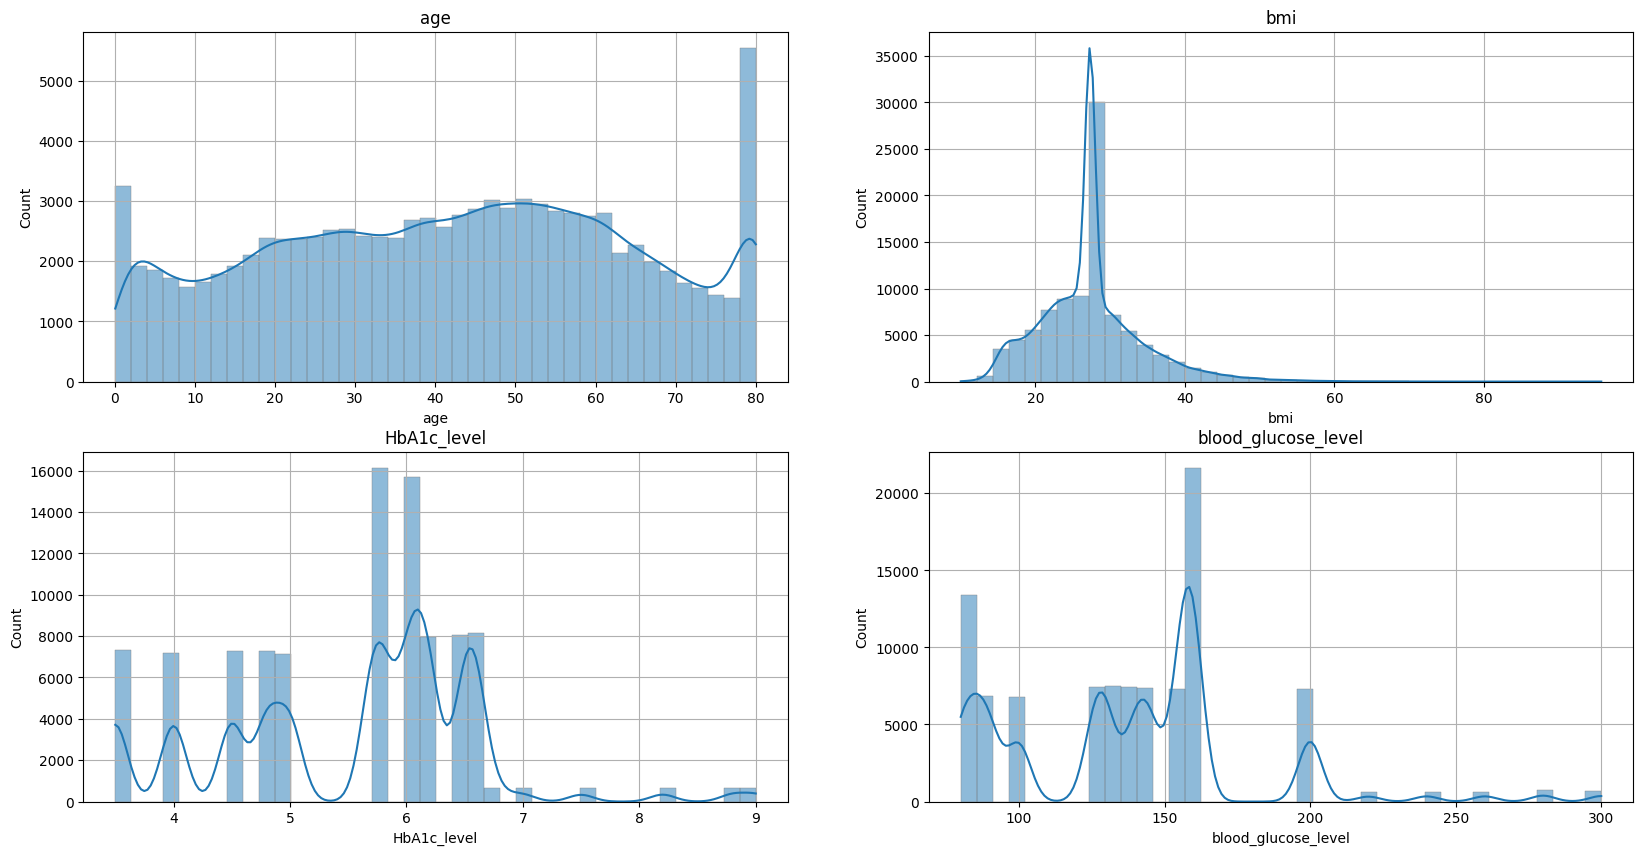

In [ ]:
width = 2
height = (len(numeric) + width - 1)// width

fig, axes = plt.subplots(nrows=height, ncols=width, figsize=(width*10, height*5))
axes = axes.flatten()

for idx, column_name in enumerate(numeric):
    sns.histplot(data=df, x=column_name, bins=40,
                 kde=True, edgecolor='gray', linewidth=0.3, ax=axes[idx])
    axes[idx].set_title(column_name)
    axes[idx].grid()

In [ ]:
df["bmi"].value_counts().head(5)

bmi
27.32    21659
23.00      103
27.12      101
27.80      100
24.96      100
Name: count, dtype: int64

In [ ]:
df["bmi"].sort_values(ascending=False).head(20)

87843    95.69
76093    95.22
69549    91.82
96066    88.76
4551     88.72
90043    87.70
22454    87.51
24186    83.74
71485    81.73
20591    79.48
58318    79.46
54336    75.78
20355    73.77
28645    72.89
21960    72.28
82244    72.21
71090    72.03
78960    71.55
63048    70.96
7480     69.66
Name: bmi, dtype: float64

- Возраст имеет выраженные пики на концах значений
- ИМТ имеет ярко-выраженный пик и правосторонний хвост (выбросы). Выбросы имеют несколько значений, но имеют аномальные значения.
- Уровень HbA1c и уровень глюкозы имеют определённые дискретные значения, которые не имеют ярко-выраженного распределения.

Категориальный признаки

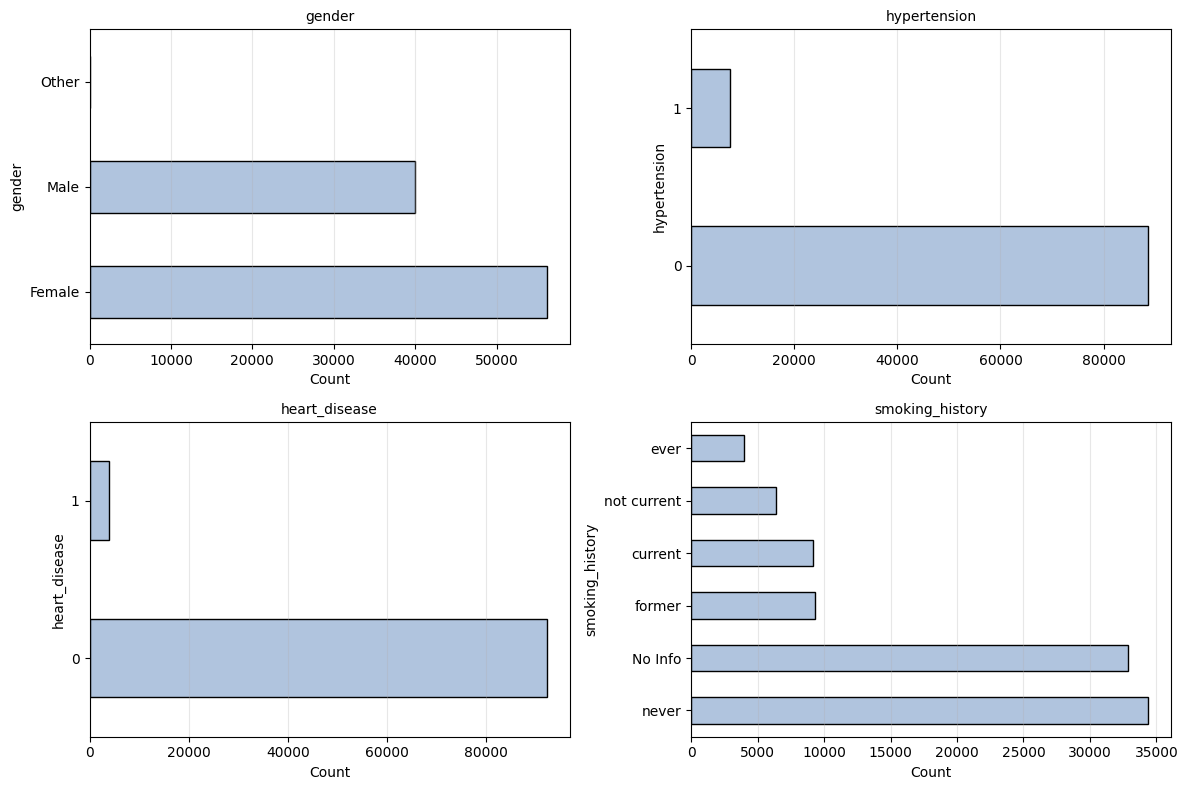

In [ ]:
width = 2
height = (len(categorial) + width - 1)// width

fig, axes = plt.subplots(height, width, figsize=(6*width, 4*height))
axes = axes.flatten()

for i, col in enumerate(categorial):
    counts = df[col].value_counts()
    counts.plot(kind='barh', color='lightsteelblue', edgecolor='black', ax=axes[i])
    
    axes[i].set_title(f'{col}', fontsize=10)
    axes[i].set_xlabel('Count')
    axes[i].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
df['gender'].value_counts(normalize=True)

gender
Female    0.584122
Male      0.415691
Other     0.000187
Name: proportion, dtype: float64

Видим, что признак "Пол" имеет третью категорию "Other", которая очень малочисленная. На таком количестве объектов модель не сможет обучиться и сделать верное предсказание. Удалим все строки, где "Пол" = "Other".

In [ ]:
df = df[df['gender'] != 'Other']

In [ ]:
df.shape

(96128, 9)

Распределение целевой переменной:

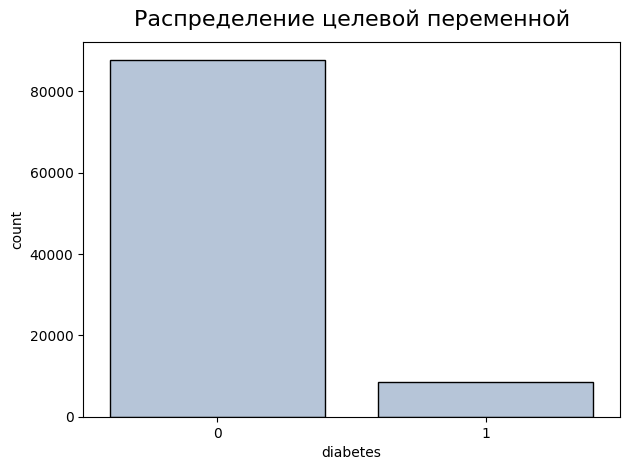

In [ ]:
sns.countplot(x=y, color='lightsteelblue', edgecolor='black')
plt.title("Распределение целевой переменной", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
y.value_counts()

diabetes
0    87646
1     8482
Name: count, dtype: int64

Число объектов с наличием диабета в 10 раз меньше, чем с отсутствием диабета, что говорит о сильном дисбалансе классов.

### Зависимость с целевой переменной

Построим матрицу зависимостей между признакими и целевой переменной:

interval columns not set, guessing: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


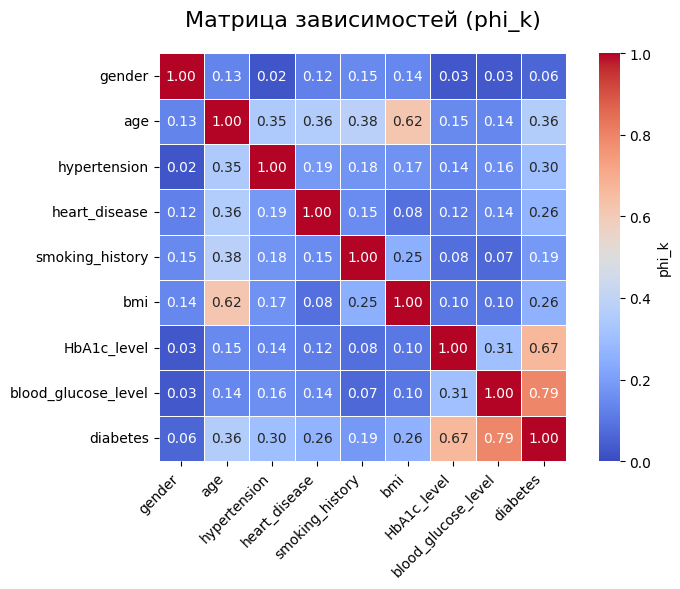

In [ ]:
df_copy = df.copy()
df_copy['diabetes'] = y
phik_matrix = df_copy.phik_matrix()

def plot_phik(phik_matrix):
    plt.figure(figsize=(8, 6))
    sns.heatmap(
        phik_matrix,
        annot=True,         
        fmt=".2f",         
        cmap="coolwarm",    
        vmin=0,
        vmax=1,          
        square=True,
        linewidths=0.5,
        cbar_kws={"label": "phi_k"}
    )

    plt.title("Матрица зависимостей (phi_k)", fontsize=16, pad=20)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_phik(phik_matrix)

Видим высокую корреляцию между уровнем глюкозы и ликированным гемоглобином и целевой переменной, что подтвержает то, что это 2 основных показателя для постановки диагоза. 

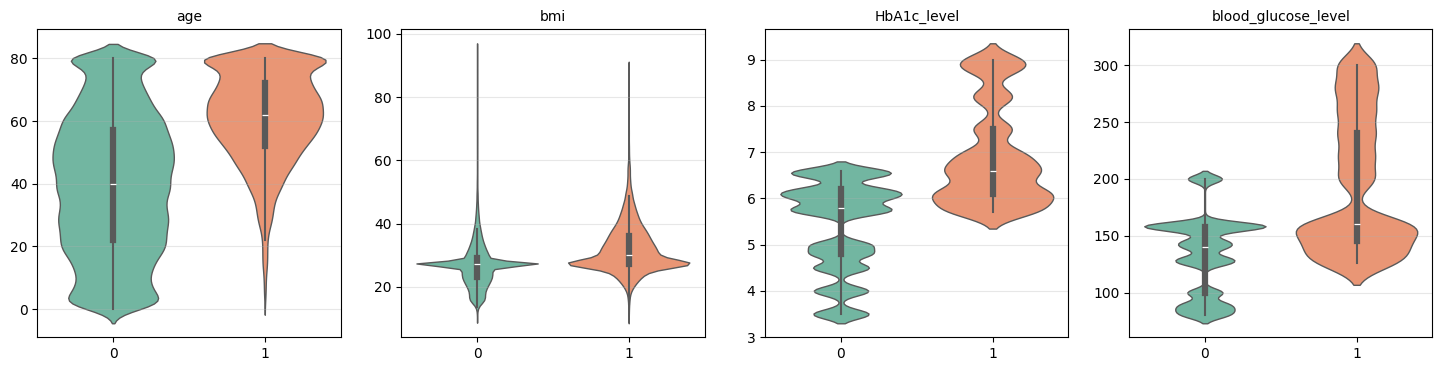

In [ ]:
# Зависимость числовых признаков и целевой переменной
n_cols = 4
n_rows = -(-len(numeric) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, num_col in enumerate(numeric):
    sns.violinplot(
        data=df,
        x='diabetes',
        y=num_col,
        hue='diabetes',
        legend=False,
        linewidth=1,
        ax=axes[i],
        palette="Set2"
    )
    axes[i].set_title(num_col, fontsize=10)
    axes[i].set_xlabel("")
    axes[i].set_ylabel("")
    axes[i].grid(axis="y", alpha=0.3)

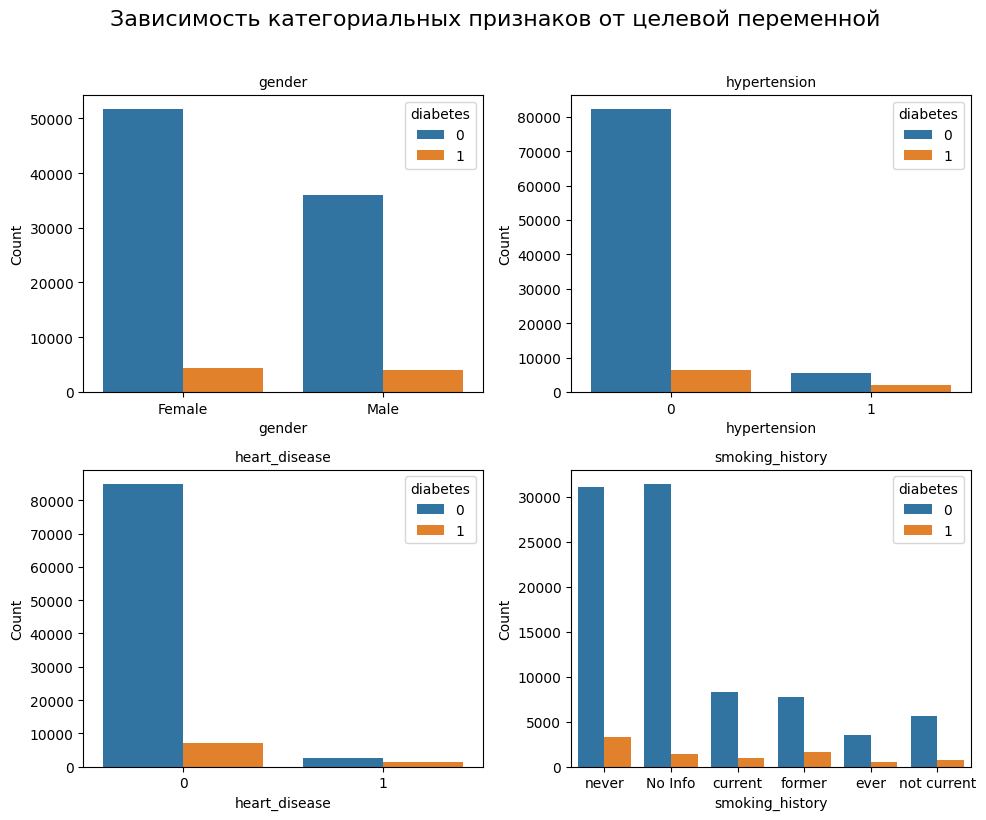

In [ ]:
# Зависимость категориальных признаков и целевой переменной
n_cols = 2
n_rows = -(-len(categorial) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorial):
    sns.countplot(data=df, x=col, hue=y,  ax=axes[i],)
    axes[i].set_title(f"{col}", fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

fig.suptitle("Зависимость категориальных признаков от целевой переменной", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

## Вывод

- Проанализирован открытый датасет на 100000 строк, который содержит 8 признаков и одну целевую переменную diabetes
- При анализе числовых признаковых было определено, что возраст имеет яркие пики около 0 и около 80. Что говорит о том, что большая часть данных собрана о детях и людях пожилого возраста. Признак индекса массы тела имеет пик на значении 27.32 - 21659 значений, предположительно этим значением заполнялись пропуски. HbA1c и Blood glucose имеют дискретные значения и несколько выраженных пиков. 
- В результате анализа категориальных признаков были удалены строки с значениями "Пол" = "Other" как самый малочисленный. 
- Матрица корреляций показала, что признаки уровень глюкозы и гликированный гемоглобин имееют сильную зависимость от целевой переменной, следовательно, являются сильными предикторами.
- Целевая прееменная имеет 2 значения: 0 - нет диабета, 1 - есть диабет. Наличие диабета является минорным классом, так как число объектов с ним в 10 раз меньше класса 0.
